# Q-Learning with Gymnasium CliffWalking-v1
## Cliff avoidance, Q-table convergence, exact optimal Q*, greedy policy, and rendered trained agent

This notebook uses the **built-in Gymnasium `CliffWalking-v1` environment**.

The agent starts at the lower-left corner of a 4×12 grid and must reach the goal at the lower-right corner. A cliff occupies most of the bottom row.

If the agent steps into the cliff:

- it receives a large negative reward;
- it is returned to the start.

This is a classic tabular control problem and is especially useful later when comparing **Q-Learning with SARSA**.

In [1]:
%pip install -q "gymnasium[toy-text]" imageio pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 35.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import imageio.v2 as imageio

from IPython.display import Image as IPyImage, display

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_rows", 600)
pd.set_option("display.max_columns", 20)

## 1. Environment and MDP Definition

### State space

CliffWalking has 48 discrete state indices:

$$
\mathcal S=\{0,1,\ldots,47\}.
$$

The environment corresponds to a 4×12 grid.

### Action space

There are four actions:

- 0 = Up
- 1 = Right
- 2 = Down
- 3 = Left

### Reward

$$
R=
\begin{cases}
-100, & \text{agent steps into the cliff}\\
-1, & \text{every other movement}
\end{cases}
$$

### Start and goal

The standard start is the lower-left cell.

The goal is the lower-right cell.

### Terminal condition

The episode terminates when the agent reaches the goal.

### Objective

Reach the goal while minimizing cumulative penalty.

Environment: CliffWalking-v1
Observation space: Discrete(48)
Action space: Discrete(4)


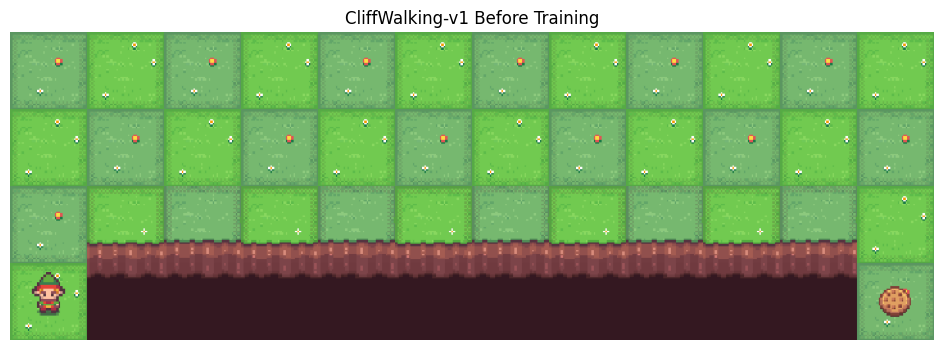

In [3]:
def make_cliff(render_mode=None):
    for env_id in ["CliffWalking-v1", "CliffWalking-v0"]:
        try:
            return gym.make(env_id, render_mode=render_mode), env_id
        except gym.error.Error:
            pass
    raise RuntimeError("CliffWalking is not available in this Gymnasium installation.")

env, ENV_ID = make_cliff()
render_env, _ = make_cliff(render_mode="rgb_array")

GAMMA = 0.95
ACTION_NAMES = ["Up", "Right", "Down", "Left"]

print("Environment:", ENV_ID)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

state, _ = render_env.reset(seed=7)

plt.figure(figsize=(12, 4))
plt.imshow(render_env.render())
plt.axis("off")
plt.title(f"{ENV_ID} Before Training")
plt.show()

## 2. Q-Learning Update

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_aQ(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

The agent explores with an $\epsilon$-greedy behavior policy but learns toward the greedy target

$$
\max_a Q(S_{t+1},a).
$$

This is why Q-Learning is **off-policy**.

## 3. Exact Optimal Q-Table $Q^*$

The deterministic CliffWalking transition model allows the exact optimal Q-values to be calculated with value iteration.

In [4]:
def value_iteration_from_model(env, gamma=0.95, theta=1e-12):
    """Compute exact Q* from the environment's tabular transition model P."""
    P = env.unwrapped.P
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    V = np.zeros(n_states)

    while True:
        V_new = np.zeros_like(V)

        for s in range(n_states):
            action_values = []

            for a in range(n_actions):
                q = 0.0

                for prob, s_next, reward, terminated in P[s][a]:
                    bootstrap = 0.0 if terminated else gamma * V[s_next]
                    q += prob * (reward + bootstrap)

                action_values.append(q)

            V_new[s] = max(action_values)

        if np.max(np.abs(V_new - V)) < theta:
            V = V_new
            break

        V = V_new

    Q_star = np.zeros((n_states, n_actions))

    for s in range(n_states):
        for a in range(n_actions):
            for prob, s_next, reward, terminated in P[s][a]:
                bootstrap = 0.0 if terminated else gamma * V[s_next]
                Q_star[s, a] += prob * (reward + bootstrap)

    return Q_star

In [5]:
Q_star = value_iteration_from_model(env, gamma=GAMMA)

q_star_df = pd.DataFrame(
    Q_star,
    index=[f"State {s}" for s in range(env.observation_space.n)],
    columns=ACTION_NAMES
)

print("Exact optimal Q-table Q*:")
display(q_star_df.round(3))

Exact optimal Q-table Q*:


,Up,Right,Down,Left
State 0,-10.734,-10.247,-10.247,-10.734
State 1,-10.247,-9.733,-9.733,-10.734
State 2,-9.733,-9.193,-9.193,-10.247
State 3,-9.193,-8.624,-8.624,-9.733
State 4,-8.624,-8.025,-8.025,-9.193
State 5,-8.025,-7.395,-7.395,-8.624
State 6,-7.395,-6.732,-6.732,-8.025
State 7,-6.732,-6.033,-6.033,-7.395
State 8,-6.033,-5.298,-5.298,-6.732
State 9,-5.298,-4.524,-4.524,-6.033


## 4. Train the Q-Learning Agent

Parameters:

$$
\alpha=0.5,\qquad \gamma=0.95.
$$

The first 60 individual Q updates are saved.

In [6]:
def train_q_learning(
    n_episodes=12000,
    alpha=0.5,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.9993,
    seed=17
):
    rng = np.random.default_rng(seed)

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    history = []
    update_log = []
    visit_counts = np.zeros(n_states, dtype=int)

    epsilon = epsilon_start
    update_number = 0

    for episode in range(1, n_episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0

        for step in range(1, 1001):
            visit_counts[state] += 1

            if rng.random() < epsilon:
                action = int(rng.integers(n_actions))
                selection = "explore"
            else:
                best_actions = np.flatnonzero(np.isclose(Q[state], Q[state].max()))
                action = int(rng.choice(best_actions))
                selection = "exploit"

            next_state, reward, terminated, truncated, _ = env.step(action)

            old_q = Q[state, action]
            max_next_q = 0.0 if terminated else np.max(Q[next_state])
            target = reward if terminated else reward + gamma * max_next_q
            td_error = target - old_q
            Q[state, action] += alpha * td_error

            update_number += 1

            if update_number <= 60:
                update_log.append({
                    "Update": update_number,
                    "Episode": episode,
                    "Step": step,
                    "State": state,
                    "Action": ACTION_NAMES[action],
                    "Reward": reward,
                    "Next State": next_state,
                    "Max Next Q": max_next_q,
                    "Old Q": old_q,
                    "TD Target": target,
                    "TD Error": td_error,
                    "New Q": Q[state, action],
                    "Epsilon": epsilon
                })

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        visited = visit_counts > 0
        rmse = np.sqrt(np.mean((Q[visited] - Q_star[visited]) ** 2))

        history.append({
            "Episode": episode,
            "Return": total_reward,
            "Episode Length": step,
            "Epsilon": epsilon,
            "Visited States": visited.sum(),
            "Q RMSE on Visited States": rmse
        })

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, pd.DataFrame(history), pd.DataFrame(update_log), visit_counts

Q, history, update_log, visit_counts = train_q_learning()

print("Training complete.")
print("Visited states:", int((visit_counts > 0).sum()))
print("Final RMSE on visited states:", history["Q RMSE on Visited States"].iloc[-1])

Training complete.
Visited states: 37
Final RMSE on visited states: 5.788805137013191e-15


## 5. First 60 Q-Value Updates

In [7]:
display(update_log.round(4))

,Update,Episode,Step,State,Action,Reward,Next State,Max Next Q,Old Q,TD Target,TD Error,New Q,Epsilon
0,1,1,1,36,Up,-1,24,0.0000,0.0000,-1.0000,-1.0000,-0.5000,1.0
1,2,1,2,24,Up,-1,12,0.0000,0.0000,-1.0000,-1.0000,-0.5000,1.0
2,3,1,3,12,Up,-1,0,0.0000,0.0000,-1.0000,-1.0000,-0.5000,1.0
3,4,1,4,0,Up,-1,0,0.0000,0.0000,-1.0000,-1.0000,-0.5000,1.0
4,5,1,5,0,Down,-1,12,0.0000,0.0000,-1.0000,-1.0000,-0.5000,1.0
5,6,1,6,12,Down,-1,24,0.0000,0.0000,-1.0000,-1.0000,-0.5000,1.0
6,7,1,7,24,Down,-1,36,0.0000,0.0000,-1.0000,-1.0000,-0.5000,1.0
7,8,1,8,36,Right,-100,36,0.0000,0.0000,-100.0000,-100.0000,-50.0000,1.0
8,9,1,9,36,Down,-1,36,0.0000,0.0000,-1.0000,-1.0000,-0.5000,1.0
9,10,1,10,36,Left,-1,36,0.0000,0.0000,-1.0000,-1.0000,-0.5000,1.0


## 6. Convergence Graph

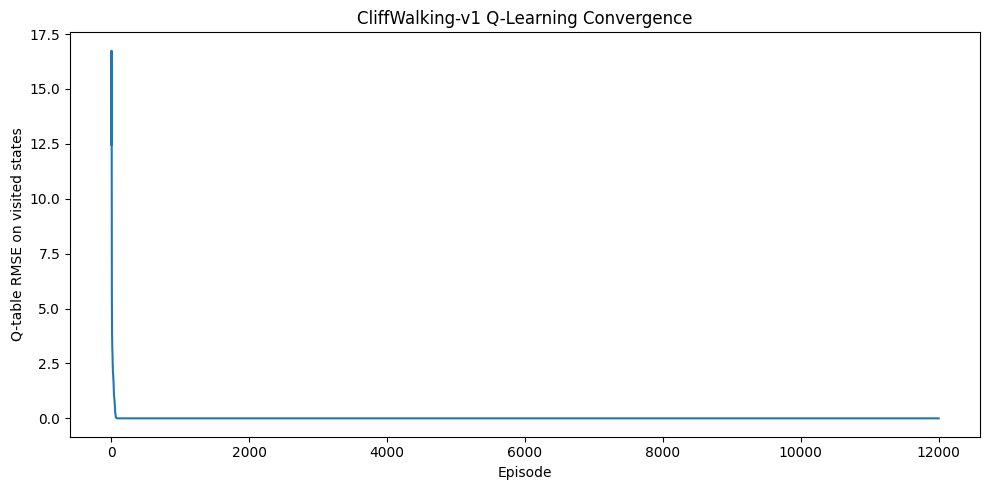

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(history["Episode"], history["Q RMSE on Visited States"])
plt.xlabel("Episode")
plt.ylabel("Q-table RMSE on visited states")
plt.title(f"{ENV_ID} Q-Learning Convergence")
plt.tight_layout()
plt.show()

## 7. Learned Q-Table vs. Exact Optimal Q-Table

In [9]:
learned_q_df = pd.DataFrame(
    Q,
    index=[f"State {s}" for s in range(env.observation_space.n)],
    columns=ACTION_NAMES
)

comparison = pd.concat(
    {"Learned Q": learned_q_df.round(3), "Exact Q*": q_star_df.round(3)},
    axis=1
)

display(comparison)

Learned Q                           Exact Q*                    \
                Up    Right     Down    Left       Up    Right     Down   
State 0    -10.734  -10.247  -10.247 -10.734  -10.734  -10.247  -10.247   
State 1    -10.247   -9.733   -9.733 -10.734  -10.247   -9.733   -9.733   
State 2     -9.733   -9.193   -9.193 -10.247   -9.733   -9.193   -9.193   
State 3     -9.193   -8.624   -8.624  -9.733   -9.193   -8.624   -8.624   
State 4     -8.624   -8.025   -8.025  -9.193   -8.624   -8.025   -8.025   
State 5     -8.025   -7.395   -7.395  -8.624   -8.025   -7.395   -7.395   
State 6     -7.395   -6.732   -6.732  -8.025   -7.395   -6.732   -6.732   
State 7     -6.732   -6.033   -6.033  -7.395   -6.732   -6.033   -6.033   
State 8     -6.033   -5.298   -5.298  -6.732   -6.033   -5.298   -5.298   
State 9     -5.298   -4.524   -4.524  -6.033   -5.298   -4.524   -4.524   
State 10    -4.524   -3.710   -3.710  -5.298   -4.524   -3.710   -3.710   
State 11    -3.710   -3.710   -2.852  -4.524   -3.710   -3.710   -2.852   
State 12   -10.734   -9.733   -9.733 -10.247  -10.734   -9.733   -9.733   
State 13   -10.247   -9.193   -9.193 -10.247  -10.247   -9.193   -9.193   
State 14    -9.733   -8.624   -8.624  -9.733   -9.733   -8.624   -8.624   
State 15    -9.193   -8.025   -8.025  -9.193   -9.193   -8.025   -8.025   
State 16    -8.624   -7.395   -7.395  -8.624   -8.624   -7.395   -7.395   
State 17    -8.025   -6.732   -6.732  -8.025   -8.025   -6.732   -6.732   
State 18    -7.395   -6.033   -6.033  -7.395   -7.395   -6.033   -6.033   
State 19    -6.732   -5.298   -5.298  -6.732   -6.732   -5.298   -5.298   
State 20    -6.033   -4.524   -4.524  -6.033   -6.033   -4.524   -4.524   
State 21    -5.298   -3.710   -3.710  -5.298   -5.298   -3.710   -3.710   
State 22    -4.524   -2.852   -2.852  -4.524   -4.524   -2.852   -2.852   
State 23    -3.710   -2.852   -1.950  -3.710   -3.710   -2.852   -1.950   
State 24   -10.247   -9.193  -10.247  -9.733  -10.247   -9.193  -10.247   
State 25    -9.733   -8.624 -109.247  -9.733   -9.733   -8.624 -109.247   
State 26    -9.193   -8.025 -109.247  -9.193   -9.193   -8.025 -109.247   
State 27    -8.624   -7.395 -109.247  -8.624   -8.624   -7.395 -109.247   
State 28    -8.025   -6.732 -109.247  -8.025   -8.025   -6.732 -109.247   
State 29    -7.395   -6.033 -109.247  -7.395   -7.395   -6.033 -109.247   
State 30    -6.732   -5.298 -109.247  -6.732   -6.732   -5.298 -109.247   
State 31    -6.033   -4.524 -109.247  -6.033   -6.033   -4.524 -109.247   
State 32    -5.298   -3.710 -109.247  -5.298   -5.298   -3.710 -109.247   
State 33    -4.524   -2.852 -109.247  -4.524   -4.524   -2.852 -109.247   
State 34    -3.710   -1.950 -109.247  -3.710   -3.710   -1.950 -109.247   
State 35    -2.852   -1.950   -1.000  -2.852   -2.852   -1.950   -1.000   
State 36    -9.733 -109.247  -10.247 -10.247   -9.733 -109.247  -10.247   
State 37     0.000    0.000    0.000   0.000   -9.193 -109.247 -109.247   
State 38     0.000    0.000    0.000   0.000   -8.624 -109.247 -109.247   
State 39     0.000    0.000    0.000   0.000   -8.025 -109.247 -109.247   
State 40     0.000    0.000    0.000   0.000   -7.395 -109.247 -109.247   
State 41     0.000    0.000    0.000   0.000   -6.732 -109.247 -109.247   
State 42     0.000    0.000    0.000   0.000   -6.033 -109.247 -109.247   
State 43     0.000    0.000    0.000   0.000   -5.298 -109.247 -109.247   
State 44     0.000    0.000    0.000   0.000   -4.524 -109.247 -109.247   
State 45     0.000    0.000    0.000   0.000   -3.710 -109.247 -109.247   
State 46     0.000    0.000    0.000   0.000   -2.852   -1.000 -109.247   
State 47     0.000    0.000    0.000   0.000   -1.950   -1.000   -1.000   

                   
             Left  
State 0   -10.734  
State 1   -10.734  
State 2   -10.247  
State 3    -9.733  
State 4    -9.193  
State 5    -8.624  
State 6    -8.025  
State 7    -7.395  
State 8    -6.732  
State 9    -6.033  
State 10   -5.298 

## 8. Visualize the Learned Greedy Policy

For the 4×12 board:

- `S` = start;
- `C` = cliff;
- `G` = goal;
- arrows = greedy action selected from the learned Q-table.

In [10]:
arrows = np.array(["↑", "→", "↓", "←"])
policy_grid = []

for r in range(4):
    row = []

    for c in range(12):
        s = r * 12 + c

        if r == 3 and c == 0:
            row.append("S" + arrows[np.argmax(Q[s])])
        elif r == 3 and 1 <= c <= 10:
            row.append("C")
        elif r == 3 and c == 11:
            row.append("G")
        else:
            row.append(arrows[np.argmax(Q[s])])

    policy_grid.append(row)

policy_df = pd.DataFrame(policy_grid)
display(policy_df)

,0,1,2,3,4,5,6,7,8,9,10,11
0,→,→,→,→,→,→,→,→,→,→,→,↓
1,→,→,→,→,→,→,→,→,→,→,→,↓
2,→,→,→,→,→,→,→,→,→,→,→,↓
3,S↑,C,C,C,C,C,C,C,C,C,C,G


## 9. Evaluate the Trained Agent

In [11]:
def evaluate_agent(Q, n_episodes=200):
    returns = []
    lengths = []
    successes = 0

    for episode in range(n_episodes):
        state, _ = env.reset(seed=30000 + episode)
        total_reward = 0.0

        for step in range(1, 1001):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward

            if terminated or truncated:
                successes += int(terminated)
                break

        returns.append(total_reward)
        lengths.append(step)

    return {
        "Success Rate": successes / n_episodes,
        "Mean Return": np.mean(returns),
        "Mean Episode Length": np.mean(lengths)
    }

evaluation = evaluate_agent(Q)
display(pd.DataFrame([evaluation]).round(3))

,Success Rate,Mean Return,Mean Episode Length
0,1.0,-13.0,13.0


## 10. Run the Trained Agent in the Actual Environment

The trained greedy policy is rendered frame-by-frame with Gymnasium and shown inline as a GIF.

In [12]:
def save_gif(frames, filename, duration=0.45):
    imageio.mimsave(filename, frames, duration=duration, loop=0)
    display(IPyImage(filename=filename))

Actions: ['Up', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Right', 'Down']
Number of steps: 13
Total reward: -13.0


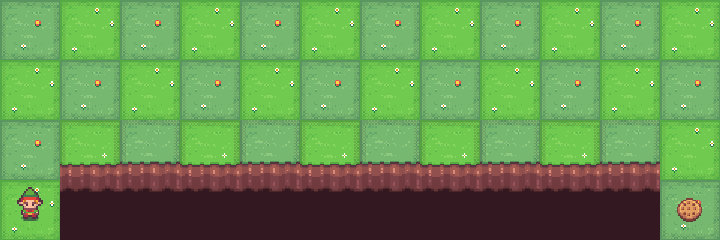

In [13]:
def record_trained_agent(Q, filename="cliffwalking_trained_agent.gif"):
    frames = []
    state, _ = render_env.reset(seed=123)
    frames.append(render_env.render())

    actions = []
    total_reward = 0.0

    for _ in range(200):
        action = int(np.argmax(Q[state]))
        actions.append(ACTION_NAMES[action])

        state, reward, terminated, truncated, _ = render_env.step(action)
        total_reward += reward
        frames.append(render_env.render())

        if terminated or truncated:
            break

    print("Actions:", actions)
    print("Number of steps:", len(actions))
    print("Total reward:", total_reward)

    save_gif(frames, filename, duration=0.35)

record_trained_agent(Q)

## 11. Why CliffWalking Is Important for the Next Portfolio Section

CliffWalking is a standard example for comparing Q-Learning and SARSA.

Q-Learning uses

$$
R_{t+1}+\gamma\max_aQ(S_{t+1},a),
$$

whereas SARSA uses

$$
R_{t+1}+\gamma Q(S_{t+1},A_{t+1}).
$$

Using the same CliffWalking environment later will make the difference between **off-policy Q-Learning** and **on-policy SARSA** easy to demonstrate.